Mount Google Drive

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Path & File Check

In [2]:
# Pindah ke folder tempat file CSV dan notebook
%cd "/content/drive/MyDrive/Colab Notebooks/igar"

# Cek apakah file CSV-nya ada
!ls

/content/drive/MyDrive/Colab Notebooks/igar
confusion_matrix_perbandingan.png  igar_deepl
hasil_training_perbandingan.png    VADER_labeled.csv


Import Lib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Setting plot
plt.style.use('ggplot')
sns.set_style('whitegrid')

print("Library berhasil diimport!")

Library berhasil diimport!


Load Data & Eksplorasi Awal

In [4]:
# Baca file CSV
df = pd.read_csv('VADER_labeled.csv')

# Lihat 5 data teratas
print("=== 5 DATA PERTAMA ===")
df.head()

=== 5 DATA PERTAMA ===


,app,content,score,at,appVersion,translation,vader_neg,vader_neu,vader_pos,vader_compound,vader_label,vader_confidence
0,satusehat,Lelet....,1,2021-10-14 06:05:05,3.4.0,Find ....,0.000,1.000,0.000,0.0000,neutral,0.0000
1,satusehat,Josss,5,2021-10-14 06:04:17,3.4.6,JOSSS,0.000,1.000,0.000,0.0000,neutral,0.0000
2,satusehat,Jadi lebih waspada sama bahaya covid 19,5,2021-10-14 06:02:30,3.4.6,So more alert to the dangers of Covid 19,0.247,0.540,0.214,-0.1100,negative,0.1100
3,satusehat,Saya sudah vaksin kedua tapi sertifikat vaksin...,2,2021-10-14 06:02:24,NaN,I have a second vaccine but my vaccine certifi...,0.000,1.000,0.000,0.0000,neutral,0.0000
4,satusehat,Mantap...sangat membantu,5,2021-10-14 06:01:28,3.4.6,Great ... very helpful,0.000,0.218,0.782,0.8016,positive,0.8016


In [5]:
KOLOM_TEKS = 'content'
KOLOM_LABEL = 'vader_label'

print(f"Kolom Teks yang dipakai: {KOLOM_TEKS}")
print(f"Kolom Label yang dipakai: {KOLOM_LABEL}")

print("\n=== INFORMASI DATASET ===")
print(f"Jumlah data: {len(df)} baris")
print(f"Jumlah kolom: {len(df.columns)}")
print("\nJenis data per kolom:")
print(df.dtypes)

# Cek data kosong
print("\n=== CEK DATA KOSONG ===")
print(df.isnull().sum())

# Handling
df = df.dropna(subset=[KOLOM_TEKS, KOLOM_LABEL])

# Hapus teks yang isinya cuma spasi atau string kosong ""
df = df[df[KOLOM_TEKS].str.strip() != '']

print(f"\n✅ Sisa data setelah menghapus data kosong: {len(df)} baris")

Kolom Teks yang dipakai: content
Kolom Label yang dipakai: vader_label

=== INFORMASI DATASET ===
Jumlah data: 617722 baris
Jumlah kolom: 12

Jenis data per kolom:
app                  object
content              object
score                 int64
at                   object
appVersion           object
translation          object
vader_neg           float64
vader_neu           float64
vader_pos           float64
vader_compound      float64
vader_label          object
vader_confidence    float64
dtype: object

=== CEK DATA KOSONG ===
app                     0
content                26
score                   0
at                      0
appVersion          90403
translation          7775
vader_neg               0
vader_neu               0
vader_pos               0
vader_compound          0
vader_label             0
vader_confidence        0
dtype: int64

✅ Sisa data setelah menghapus data kosong: 617696 baris


Data Sampling

Data sekarang berjumlah: 30000 baris

=== SEBARAN SENTIMEN ===
vader_label
positive    15834
neutral      8387
negative     5779
Name: count, dtype: int64


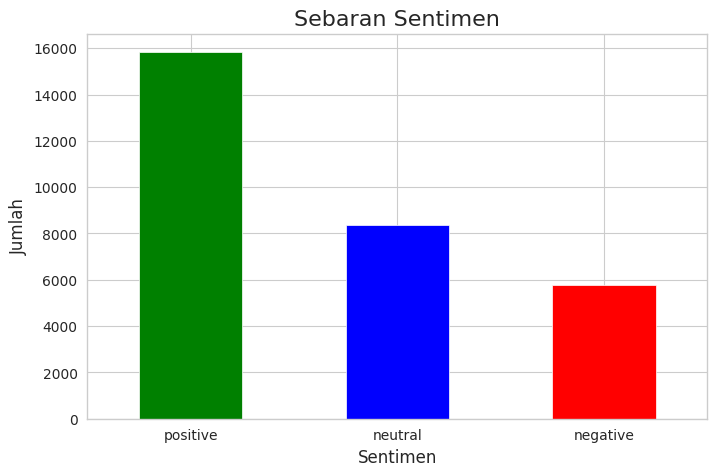

In [6]:
# Ambil 30.000 sampel secara acak (pakai random_state biar hasilnya konsisten)
df_sampel = df.sample(n=30000, random_state=42).copy()

print(f"Data sekarang berjumlah: {len(df_sampel)} baris")

# Cek sebaran labelnya
print("\n=== SEBARAN SENTIMEN ===")
print(df_sampel[KOLOM_LABEL].value_counts())

# Visualisasi sebaran label
plt.figure(figsize=(8,5))
df_sampel[KOLOM_LABEL].value_counts().plot(kind='bar', color=['green', 'blue', 'red'])
plt.title('Sebaran Sentimen', fontsize=16)
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.show()

Prepocessing

In [7]:
# Fungsi untuk membersihkan teks
def bersihkan_teks(text):
    # Pastikan dalam format string
    text = str(text)

    # 1. Ubah ke huruf kecil semua (lowercase)
    text = text.lower()

    # 2. Hapus mention (@username) dan link (http, https, www)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Hapus angka, tanda baca, dan karakter aneh (hanya huruf a-z dan spasi)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 4. Hapus spasi berlebih (lebih dari 1 spasi diubah jadi 1 spasi)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Terapkan fungsi ke kolom teks
print("Sedang membersihkan 30.000 data... (tunggu 5-10 detik)")
df_sampel['teks_bersih'] = df_sampel[KOLOM_TEKS].apply(bersihkan_teks)

# Cek hasil
print("\n=== CONTOH TEKS SETELAH DIBERSIHKAN ===")
df_sampel[[KOLOM_TEKS, 'teks_bersih']].head(10)

Sedang membersihkan 30.000 data... (tunggu 5-10 detik)

=== CONTOH TEKS SETELAH DIBERSIHKAN ===


,content,teks_bersih
392018,Oke,oke
599000,"Periksaaa periksaa periksaaa aja terus, yg ben...",periksaaa periksaa periksaaa aja terus yg bene...
575609,Sangat puas,sangat puas
119303,Para bangsat,para bangsat
34719,Saya hsl antigen terakhir sdh negativ setelah ...,saya hsl antigen terakhir sdh negativ setelah ...
269317,Ini app jkn gimana sih ko auto logout??! Pas m...,ini app jkn gimana sih ko auto logout pas mau ...
48265,Siip,siip
117114,Sudah berkali² di download muter terus gak bis...,sudah berkali di download muter terus gak bisa...
374916,biar ga ilang,biar ga ilang
203763,Kpd Yth BPJS. Seminggu yg lalu sy dirujuk oleh...,kpd yth bpjs seminggu yg lalu sy dirujuk oleh ...


Encoding Label

In [8]:
# Buat Label Encoder
encoder = LabelEncoder()

# Ubah label (misal 'positif' -> 2, 'netral' -> 1, 'negatif' -> 0)
df_sampel['label_angka'] = encoder.fit_transform(df_sampel[KOLOM_LABEL])

# Lihat mapping-nya
print("=== MAPPING LABEL ===")
for i, nama in enumerate(encoder.classes_):
    print(f"{nama} -> {i}")

print("\n=== 5 DATA SETELAH ENCODING ===")
print(df_sampel[[KOLOM_LABEL, 'label_angka']].head())

# Jumlah kelas
NUM_CLASSES = len(encoder.classes_)
print(f"\nJumlah kelas: {NUM_CLASSES}")

=== MAPPING LABEL ===
negative -> 0
neutral -> 1
positive -> 2

=== 5 DATA SETELAH ENCODING ===
       vader_label  label_angka
392018     neutral            1
599000     neutral            1
575609    positive            2
119303    negative            0
34719     negative            0

Jumlah kelas: 3


Split Data (80% Train, 10% Val, 10% Test)

In [9]:
# Siapkan X (teks) dan y (label angka)
X = df_sampel['teks_bersih'].values
y = df_sampel['label_angka'].values

# Split pertama: 80% train, 20% sisanya
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split kedua: 10% validation, 10% test (dari 20% sisanya)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"✅ Ukuran Train: {len(X_train)} data")
print(f"✅ Ukuran Validation: {len(X_val)} data")
print(f"✅ Ukuran Test: {len(X_test)} data")

✅ Ukuran Train: 24000 data
✅ Ukuran Validation: 3000 data
✅ Ukuran Test: 3000 data


Handling Imbalanced Data

In [21]:
from sklearn.utils.class_weight import compute_class_weight

print("📊 Menghitung Class Weight untuk mengatasi Imbalance Data...")

# Hitung bobot untuk setiap kelas (0=Negatif, 1=Netral, 2=Positif)
unique_classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train)

# Ubah ke format dictionary yang dimengerti Keras
class_weight_dict = dict(enumerate(class_weights))

print("Class Weight per kelas:")
for i, weight in enumerate(class_weights):
    print(f"  Kelas {i} ({encoder.classes_[i]}): {weight:.4f}")
print("(Bobot ini nanti akan dipakai saat training model di Cell 12 & 13)")

📊 Menghitung Class Weight untuk mengatasi Imbalance Data...
Class Weight per kelas:
  Kelas 0 (negative): 1.7305
  Kelas 1 (neutral): 1.1923
  Kelas 2 (positive): 0.6316
(Bobot ini nanti akan dipakai saat training model di Cell 12 & 13)


Transformasi Data

In [22]:
# Konfigurasi
VOCAB_SIZE = 10000  # Jumlah kata terbanyak yang akan diambil
MAX_LENGTH = 50     # Panjang maksimal setiap kalimat (truncating & padding)

# 1. Buat Tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# 2. Ubah teks jadi deret angka (sequences)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# 3. Padding (samain panjang semua kalimat jadi MAX_LENGTH)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

print(f"Bentuk X_train_pad: {X_train_pad.shape}")
print(f"Bentuk X_val_pad: {X_val_pad.shape}")
print(f"Bentuk X_test_pad: {X_test_pad.shape}")

# Ubah y (label) menjadi one-hot encoding untuk klasifikasi
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_cat = to_categorical(y_val, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)

print(f"Bentuk y_train_cat: {y_train_cat.shape}")

Bentuk X_train_pad: (24000, 50)
Bentuk X_val_pad: (3000, 50)
Bentuk X_test_pad: (3000, 50)
Bentuk y_train_cat: (24000, 3)


Ekstraksi Fitur

In [23]:
print("🔍 Ekstraksi Fitur menggunakan Layer Embedding (Deep Learning)")

# Tampilkan dimensi fitur sebelum dan sesudah ekstraksi
print(f"Jumlah fitur awal (Vocabulary unik): {len(tokenizer.word_index)} kata")
print(f"Jumlah fitur setelah Embedding (VOCAB_SIZE): {VOCAB_SIZE} kata unik")
print(f"Dimensi vektor per kata (EMBEDDING_DIM): 128 dimensi")
print(f"Bentuk input model: (Batch, {MAX_LENGTH}, 128)")

# Visualisasi sederhana: Tampilkan 10 kata pertama beserta vektornya (simulasi)
print("\nContoh hasil ekstraksi (Embedding) untuk kata 'aplikasi':")
print("Vektor kata 'aplikasi' memiliki 128 angka (dipelajari otomatis oleh model).")
print("✅ Proses ini menggantikan metode PCA atau Chi-Squared pada Deep Learning.")

🔍 Ekstraksi Fitur menggunakan Layer Embedding (Deep Learning)
Jumlah fitur awal (Vocabulary unik): 15766 kata
Jumlah fitur setelah Embedding (VOCAB_SIZE): 10000 kata unik
Dimensi vektor per kata (EMBEDDING_DIM): 128 dimensi
Bentuk input model: (Batch, 50, 128)

Contoh hasil ekstraksi (Embedding) untuk kata 'aplikasi':
Vektor kata 'aplikasi' memiliki 128 angka (dipelajari otomatis oleh model).
✅ Proses ini menggantikan metode PCA atau Chi-Squared pada Deep Learning.


Model & Training CNN-1D

In [24]:
# Buat Model CNN
model_cnn = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LENGTH),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile CNN
model_cnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Tampilkan ringkasan arsitektur
print("=== ARSITEKTUR 1D-CNN ===")
model_cnn.summary()

=== ARSITEKTUR 1D-CNN ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Callback EarlyStopping buat berhenti otomatis kalau validation loss gak turun
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("🟢 Memulai Training 1D-CNN...")
history_cnn = model_cnn.fit(
    X_train_pad, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[early_stop],
    verbose=1
)
print("✅ Training CNN SELESAI!")

🟢 Memulai Training 1D-CNN...
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.6130 - loss: 0.8284 - val_accuracy: 0.7940 - val_loss: 0.5395
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8327 - loss: 0.4735 - val_accuracy: 0.8460 - val_loss: 0.4284
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8836 - loss: 0.3557 - val_accuracy: 0.8437 - val_loss: 0.4242
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9096 - loss: 0.2880 - val_accuracy: 0.8427 - val_loss: 0.4479
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9247 - loss: 0.2460 - val_accuracy: 0.8463 - val_loss: 0.4720
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9385 - loss: 0.2109 - val_accuracy: 0.8357 - val_loss: 0.5174
✅ Training CNN SELESAI!


Model & Training **LSTM**

In [26]:
# 1. Buat Arsitektur LSTM
model_lstm = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128, input_length=MAX_LENGTH),
    SpatialDropout1D(0.2),
    LSTM(units=64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

# 2. COMPILE
model_lstm.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 3. Tampilkan ringkasan
print("=== ARSITEKTUR LSTM (SETELAH COMPILE) ===")
model_lstm.summary()

# 4. Training LSTM
print("\n🔵 Memulai Training LSTM...")
history_lstm = model_lstm.fit(
    X_train_pad, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_data=(X_val_pad, y_val_cat),
    # callbacks=[early_stop], # <--- DIKOMENTARI / DIHAPUS! Biar LSTM puas belajar
    verbose=1
)
print("✅ Training LSTM SELESAI!")

=== ARSITEKTUR LSTM (SETELAH COMPILE) ===


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🔵 Memulai Training LSTM...
Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 46s 226ms/step - accuracy: 0.5246 - loss: 1.0176 - val_accuracy: 0.5280 - val_loss: 1.0087
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 42s 223ms/step - accuracy: 0.5351 - loss: 0.9309 - val_accuracy: 0.5280 - val_loss: 0.9498
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 41s 218ms/step - accuracy: 0.5263 - loss: 0.9476 - val_accuracy: 0.5280 - val_loss: 0.8978
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 40s 213ms/step - accuracy: 0.5278 - loss: 0.9231 - val_accuracy: 0.5280 - val_loss: 0.8984
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 42s 220ms/step - accuracy: 0.5378 - loss: 0.8401 - val_accuracy: 0.5787 - val_loss: 0.8111
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 42s 225ms/step - accuracy: 0.5621 - loss: 0.8327 - val_accuracy: 0.5657 - val_loss: 0.8509
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 221ms/step - accuracy: 0.5597 - loss: 0.8588 - val_accuracy: 0.5650 - val_loss: 0.8488
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 82s 223ms/step 

Perbandingan Akurasi & Loss

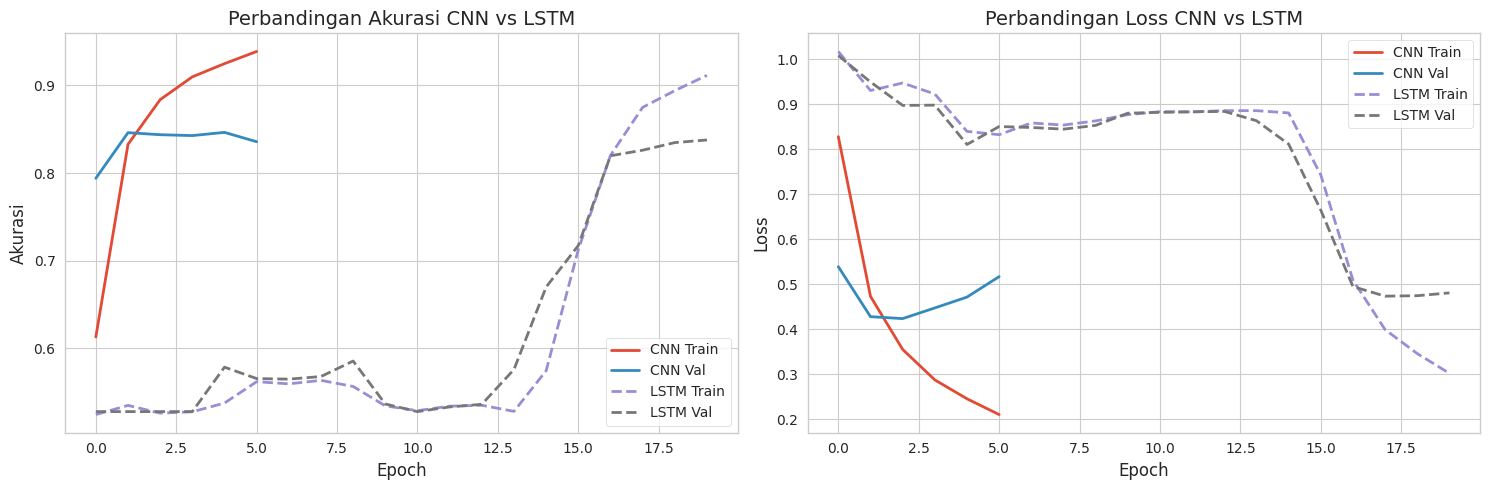

📸 Grafik berhasil disimpan sebagai 'hasil_training_perbandingan.png'


In [27]:
# Buat figure dengan 2 subplot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Grafik Akurasi ---
axes[0].plot(history_cnn.history['accuracy'], label='CNN Train', linewidth=2)
axes[0].plot(history_cnn.history['val_accuracy'], label='CNN Val', linewidth=2)
axes[0].plot(history_lstm.history['accuracy'], label='LSTM Train', linewidth=2, linestyle='--')
axes[0].plot(history_lstm.history['val_accuracy'], label='LSTM Val', linewidth=2, linestyle='--')
axes[0].set_title('Perbandingan Akurasi CNN vs LSTM', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Akurasi')
axes[0].legend()
axes[0].grid(True)

# --- Grafik Loss ---
axes[1].plot(history_cnn.history['loss'], label='CNN Train', linewidth=2)
axes[1].plot(history_cnn.history['val_loss'], label='CNN Val', linewidth=2)
axes[1].plot(history_lstm.history['loss'], label='LSTM Train', linewidth=2, linestyle='--')
axes[1].plot(history_lstm.history['val_loss'], label='LSTM Val', linewidth=2, linestyle='--')
axes[1].set_title('Perbandingan Loss CNN vs LSTM', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('hasil_training_perbandingan.png', dpi=300)  # Simpan buat laporan
plt.show()
print("📸 Grafik berhasil disimpan sebagai 'hasil_training_perbandingan.png'")

Evaluasi & Komparasi Testing

In [28]:
# Prediksi data test
y_pred_cnn = model_cnn.predict(X_test_pad)
y_pred_cnn_class = np.argmax(y_pred_cnn, axis=1)

y_pred_lstm = model_lstm.predict(X_test_pad)
y_pred_lstm_class = np.argmax(y_pred_lstm, axis=1)

# ---- Metrik Skor ----
print("="*60)
print("📊 KOMPARASI PERFORMANCE DI DATA TESTING (10% Data)")
print("="*60)

# Fungsi hitung metrik
def hitung_metrik(y_true, y_pred, nama_model):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"\n🔹 {nama_model}")
    print(f"   Akurasi  : {acc:.4f}")
    print(f"   Presisi  : {prec:.4f}")
    print(f"   Recall   : {rec:.4f}")
    print(f"   F1-Score : {f1:.4f}")
    return acc, prec, rec, f1

# Cetak hasil
metrik_cnn = hitung_metrik(y_test, y_pred_cnn_class, "1D-CNN")
metrik_lstm = hitung_metrik(y_test, y_pred_lstm_class, "LSTM")

print("\n" + "="*60)
print("🏆 KESIMPULAN:")
if metrik_cnn[0] > metrik_lstm[0]:
    print(f"✅ 1D-CNN lebih unggul dengan Akurasi {metrik_cnn[0]:.4f} vs LSTM {metrik_lstm[0]:.4f}")
else:
    print(f"✅ LSTM lebih unggul dengan Akurasi {metrik_lstm[0]:.4f} vs CNN {metrik_cnn[0]:.4f}")
print("="*60)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step
📊 KOMPARASI PERFORMANCE DI DATA TESTING (10% Data)

🔹 1D-CNN
   Akurasi  : 0.8513
   Presisi  : 0.8567
   Recall   : 0.8513
   F1-Score : 0.8527

🔹 LSTM
   Akurasi  : 0.8387
   Presisi  : 0.8417
   Recall   : 0.8387
   F1-Score : 0.8396

🏆 KESIMPULAN:
✅ 1D-CNN lebih unggul dengan Akurasi 0.8513 vs LSTM 0.8387


ROC-AUC Report

In [31]:
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import label_binarize

print("="*60)
print("📈 EVALUASI LANJUTAN (ROC-AUC & DETAIL PER KLAS)")
print("="*60)

# 1. ROC-AUC (One-vs-Rest) - Hanya bisa dihitung pakai probabilitas
# Kita sudah punya y_pred_cnn (prob) dari Cell 15, dan y_test asli
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

roc_auc_cnn = roc_auc_score(y_test_bin, y_pred_cnn, multi_class='ovr', average='weighted')
roc_auc_lstm = roc_auc_score(y_test_bin, y_pred_lstm, multi_class='ovr', average='weighted')

print(f"🏆 ROC-AUC Score (CNN)  : {roc_auc_cnn:.4f}")
print(f"🏆 ROC-AUC Score (LSTM) : {roc_auc_lstm:.4f}")

# 2. Classification Report Detail (Akurasi per kelas)
print("\n📋 Classification Report - CNN:")
print(classification_report(y_test, y_pred_cnn_class, target_names=['Negatif', 'Netral', 'Positif']))

print("\n📋 Classification Report - LSTM:")
print(classification_report(y_test, y_pred_lstm_class, target_names=['Negatif', 'Netral', 'Positif']))

# 3. Kesimpulan Akhir berdasarkan ROC-AUC
if roc_auc_cnn > roc_auc_lstm:
    print("\n✅ Berdasarkan ROC-AUC, CNN juga lebih unggul dari LSTM.")
else:
    print("\n✅ Berdasarkan ROC-AUC, LSTM lebih unggul dari CNN.")

📈 EVALUASI LANJUTAN (ROC-AUC & DETAIL PER KLAS)
🏆 ROC-AUC Score (CNN)  : 0.9534
🏆 ROC-AUC Score (LSTM) : 0.9373

📋 Classification Report - CNN:
              precision    recall  f1-score   support

     Negatif       0.70      0.81      0.75       578
      Netral       0.87      0.79      0.83       839
     Positif       0.91      0.90      0.90      1583

    accuracy                           0.85      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.86      0.85      0.85      3000


📋 Classification Report - LSTM:
              precision    recall  f1-score   support

     Negatif       0.70      0.77      0.73       578
      Netral       0.84      0.79      0.82       839
     Positif       0.89      0.89      0.89      1583

    accuracy                           0.84      3000
   macro avg       0.81      0.82      0.81      3000
weighted avg       0.84      0.84      0.84      3000


✅ Berdasarkan ROC-AUC, CNN juga lebih unggul dari LSTM.


Visualisasi Confusion Matriks

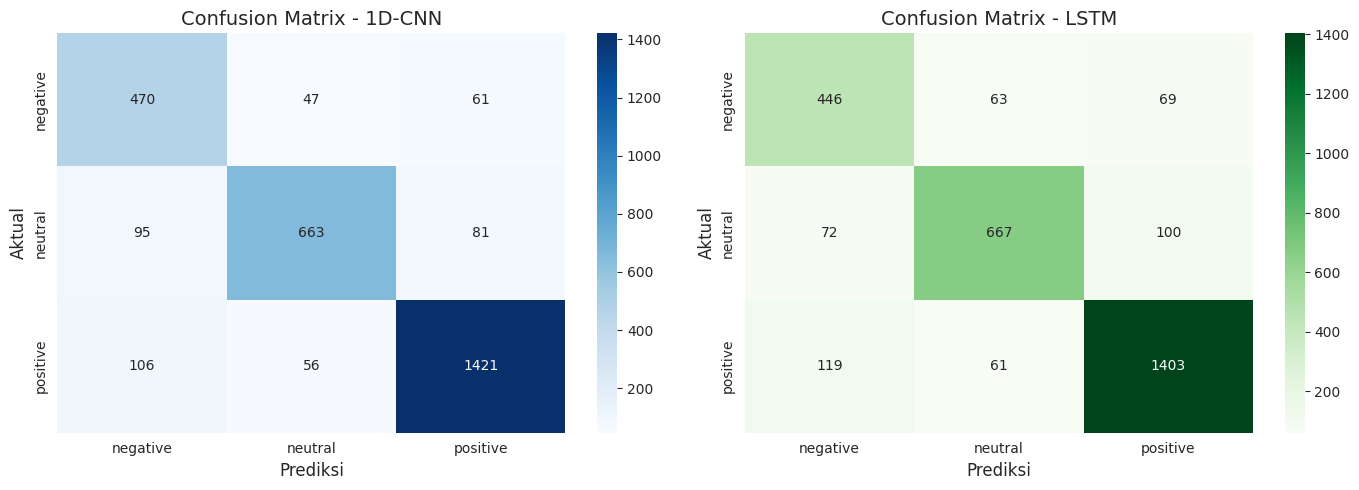

📸 Confusion Matrix berhasil disimpan sebagai 'confusion_matrix_perbandingan.png'


In [32]:
# Buat figure 2 Confusion Matrix berdampingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix CNN
cm_cnn = confusion_matrix(y_test, y_pred_cnn_class)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
axes[0].set_title('Confusion Matrix - 1D-CNN', fontsize=14)
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Confusion Matrix LSTM
cm_lstm = confusion_matrix(y_test, y_pred_lstm_class)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
axes[1].set_title('Confusion Matrix - LSTM', fontsize=14)
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('confusion_matrix_perbandingan.png', dpi=300)
plt.show()
print("📸 Confusion Matrix berhasil disimpan sebagai 'confusion_matrix_perbandingan.png'")

In [33]:
# 1. Simpan model CNN
model_cnn.save('model_cnn_terbaik.h5')
print("✅ Model CNN berhasil disimpan sebagai 'model_cnn_terbaik.h5'")

# 2. Simpan tokenizer (pake pickle)
import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("✅ Tokenizer berhasil disimpan sebagai 'tokenizer.pickle'")

# 3. Simpan encoder (biar mapping labelnya sama)
with open('encoder.pickle', 'wb') as handle:
    pickle.dump(encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("✅ Encoder berhasil disimpan sebagai 'encoder.pickle'")

✅ Model CNN berhasil disimpan sebagai 'model_cnn_terbaik.h5'
✅ Tokenizer berhasil disimpan sebagai 'tokenizer.pickle'
✅ Encoder berhasil disimpan sebagai 'encoder.pickle'
